# Segmentation model using K means clustering


## Purpose 

The purpose of this model is to be able for a company to seperate their customers into segments based on historical data. These groups will connect demographic and online behaviour/activity with spending habits allowing a company to offer a customer a tailored value proposition/ product selection based on the demographic/ behavioural aspects observed ,increasing the expected conversion of leads. The selection of variables will be based on Recency, Frequency and Monetary values which have been proven to be powerful characteristics for segmenting based on [customer behaviour and value](https://www.researchgate.net/publication/392017535_Using_RFM_Analysis_to_Predict_High-_Value_Customers).   

# Loading Environment

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA

# Loading Dataset

https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering?resource=download

The data used is artificial customer data for a grocery store. It has both physical and online data.

In [87]:
df=pd.read_csv('customer_segmentation.csv')

# Data Cleaning

In [88]:
df['ID'].nunique()

2240

In [89]:
df['Marital_Status'].value_counts()
false_mar=['YOLO','Absurd']

df=df.loc[~df['Marital_Status'].isin(false_mar)]

print(df.isna().sum())
df=df.loc[~df['Income'].isna()]



ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [90]:
df['Dt_Customer'].max()

'31-12-2013'

In [91]:
df['Dt_Customer'].min()

'01-01-2013'

In [92]:
df['ID'].count()

2212

In [93]:
df['Year_Birth']=pd.to_datetime(df['Year_Birth'],format='%Y')
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')

# Data Exploration and Feature development

In [94]:
print("Average income",df['Income'].mean().round(2))

print("number of customers", df['ID'].nunique())

reference_date=df['Dt_Customer'].max()

print("Earliest customer tenure date, which will be used as the starting date as no other date has been provided",reference_date) 
      
df['Age'] = (reference_date - df['Year_Birth']).dt.days // 365

print("Average age of customer",df['Age'].mean().round(0))

Average income 52232.51
number of customers 2212
Earliest customer tenure date, which will be used as the starting date as no other date has been provided 2014-06-29 00:00:00
Average age of customer 45.0


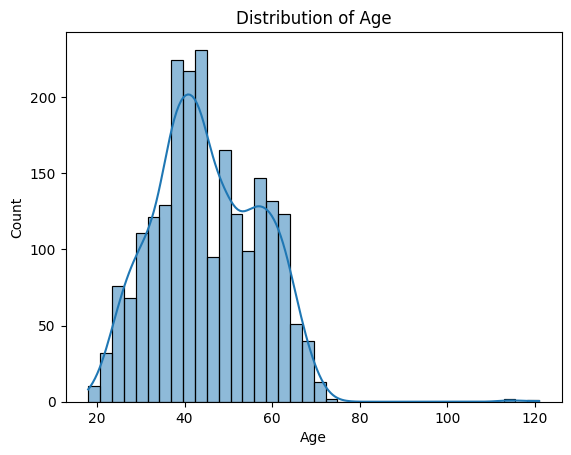

In [95]:
sns.histplot(data=df,x='Age',kde=True)
plt.title("Distribution of Age")
plt.savefig('./images/Age_Distribution.png')

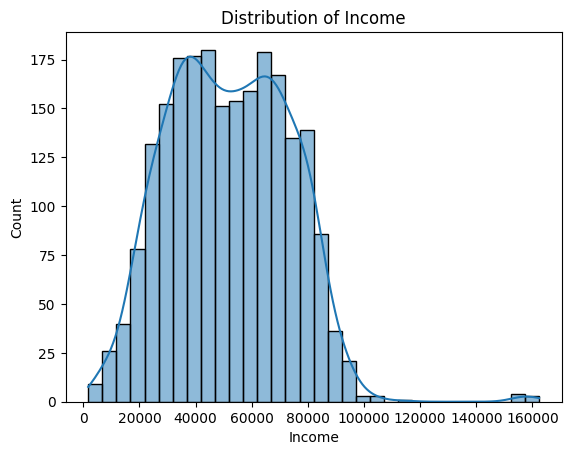

In [96]:

df=df.loc[df['Income']<200000]
sns.histplot(data=df,x='Income',kde=True)
plt.title("Distribution of Income")
plt.savefig('./images/dist_income')


In [97]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age'],
      dtype='object')

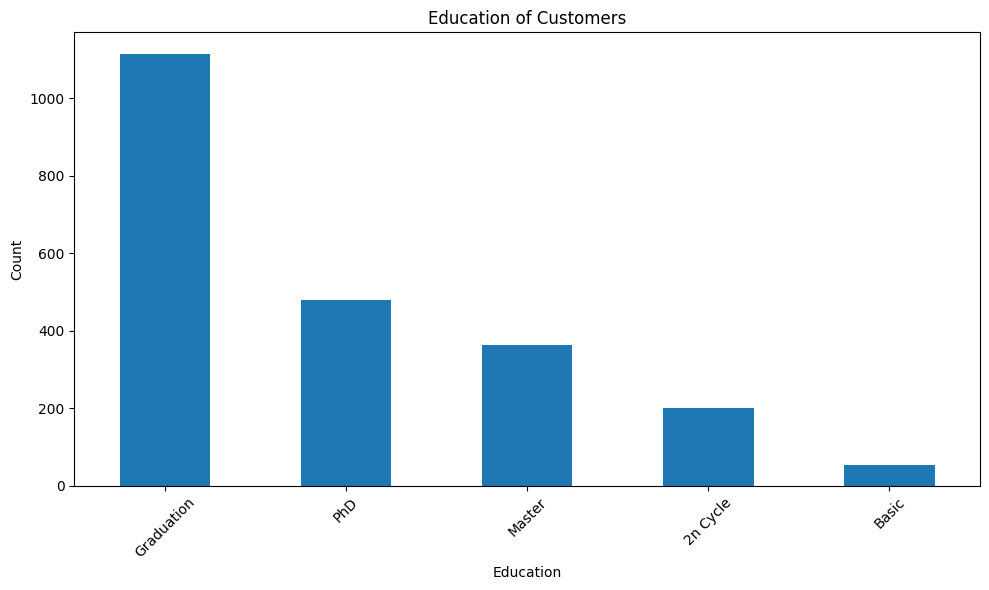

In [98]:
ed_count=df['Education'].value_counts()
ed_count.plot(kind='bar', figsize=(10, 6))
plt.title('Education of Customers')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./images/education')
plt.show()


In [99]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    572
Single      471
Divorced    232
Widow        76
Alone         3
Name: count, dtype: int64

In [100]:
df['Marital_Status'] = df['Marital_Status'].str.replace('Alone', 'Single', regex=False)

# Feature Engineering

Created total children variables

Created total spending for variable by summing up all product expenditure

Created total campaign responses from all campaigns

Changed Relationship to single or in a relationship

In [101]:
df['Total_Children']=df['Kidhome']+df['Teenhome']

In [102]:
spend=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_spend']=df[spend].sum(axis=1)

In [103]:
Response=['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
df['Response_Any']=(df[Response].sum(axis=1)>0).astype(int)



In [104]:
bins=['18','30','40','50','60','70','90']
labels=['18-29','30-39','40-49','50-59','60-69','70+']

df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)
df[['AgeGroup','Income']].groupby(['AgeGroup']).agg('mean').round(0)

C:\Users\jksta\AppData\Local\Temp\ipykernel_22332\2951445977.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[['AgeGroup','Income']].groupby(['AgeGroup']).agg('mean').round(0)


,Income
AgeGroup,
18-29,45372.0
30-39,48719.0
40-49,51451.0
50-59,56412.0
60-69,58823.0
70+,64764.0


In [105]:
reference_date=df['Dt_Customer'].max()
df['Customer_Tenure']= ((reference_date)-df['Dt_Customer']).dt.days/365


In [106]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_spend', 'Response_Any', 'AgeGroup',
       'Customer_Tenure'],
      dtype='object')

In [107]:
df['Recency']

0       58
1       38
2       26
3       26
4       94
        ..
2235    46
2236    56
2237    91
2238     8
2239    40
Name: Recency, Length: 2211, dtype: int64

In [108]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow'], dtype=object)

In [109]:

df['Relationship']=(df['Marital_Status'].str.contains('Together|Married',case=False,na=False).astype('int'))

In [110]:
spec_df=['Income','Total_Children','Total_spend','Response_Any','NumStorePurchases','NumWebPurchases','NumCatalogPurchases','NumDealsPurchases','NumWebVisitsMonth','Age','Customer_Tenure','Recency']
x=df[spec_df].copy()



In [111]:
x

,Income,Total_Children,Total_spend,Response_Any,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,Age,Customer_Tenure,Recency
0,58138.0,0,1617,1,4,8,10,3,7,57,1.816438,58
1,46344.0,2,27,0,2,1,1,2,5,60,0.309589,38
2,71613.0,0,776,0,10,8,2,1,4,49,0.854795,26
3,26646.0,1,53,0,4,2,0,2,6,30,0.380822,26
4,58293.0,1,422,0,6,5,3,5,5,33,0.441096,94
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,1,1341,0,4,9,3,2,5,47,1.043836,46
2236,64014.0,3,444,1,5,8,2,7,7,68,0.052055,56
2237,56981.0,0,1241,1,13,2,3,1,6,33,0.424658,91
2238,69245.0,1,843,0,10,6,5,2,3,58,0.427397,8


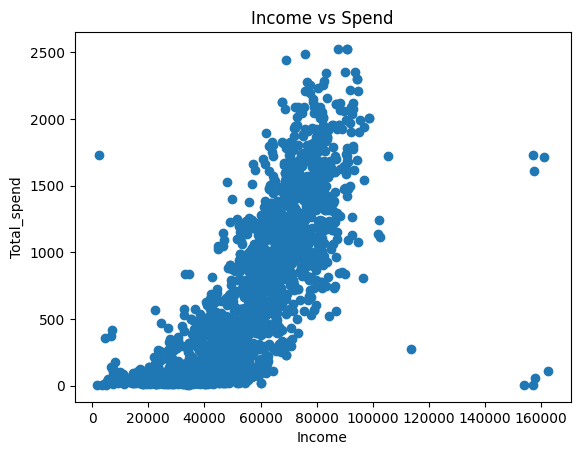

In [112]:
income=x['Income']
spend=x['Total_spend']

plt.scatter(income,spend)
plt.xlabel('Income')
plt.ylabel('Total_spend')
plt.title('Income vs Spend')
plt.show()


In [113]:
corr_map=x.corr()

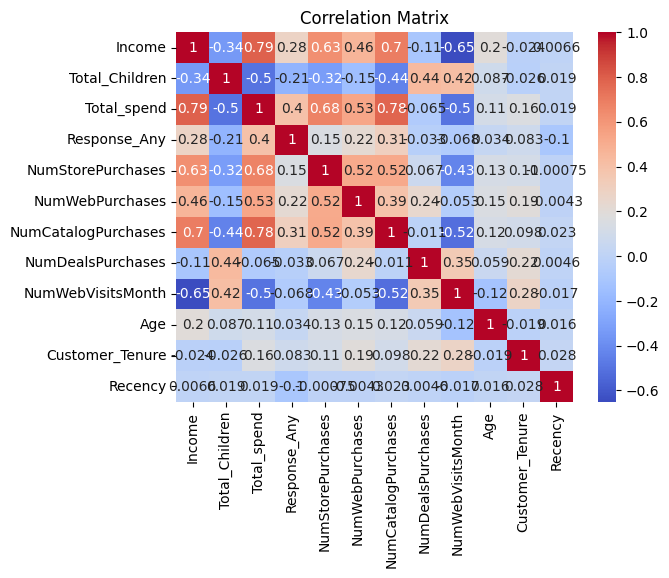

In [114]:
sns.heatmap(corr_map,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig('./images/Corr_matrix.png')
plt.show()


In [115]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_Scaled=scaler.fit_transform(x)

# 3. Fit PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_Scaled)

# 4. Add back to df
df['PCA1'] = pcs[:, 0]
df['PCA2'] = pcs[:, 1]

In [116]:
from sklearn.cluster import KMeans


In [117]:
wcss = []

Analysing the elbow diagram we can tell that 2 clusters will allow for the smallest sum of squares on average per cluster. Allowing for most well defined groupings for the dataset.

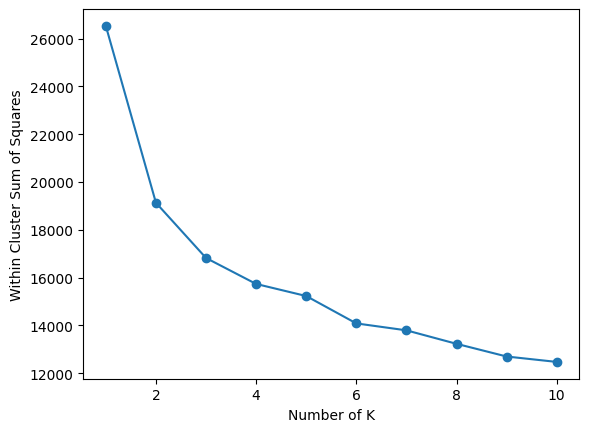

In [118]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_Scaled)
    inertias.append(kmeans.inertia_)
plt.xlabel('Number of K')
plt.ylabel('Within Cluster Sum of Squares')
plt.plot(range(1, 11), inertias, marker='o')
plt.savefig('./images/K_means.png')
plt.show()


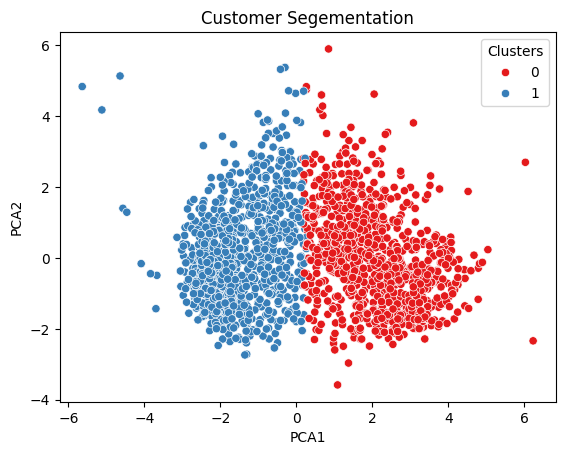

In [119]:
kmeans=KMeans(n_clusters=2)
df["Clusters"]=kmeans.fit_predict(X_Scaled)
cluster_summary=df.groupby("Clusters")[spec_df].agg('mean')

sns.scatterplot(x='PCA1',y='PCA2',hue='Clusters',data=df,palette='Set1')
plt.title("Customer Segementation")
plt.savefig('./images/seg_image.png')
plt.show()


In [120]:
cluster_summary.sort_values(['Total_spend'])

,Income,Total_Children,Total_spend,Response_Any,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,Age,Customer_Tenure,Recency
Clusters,,,,,,,,,,,,
1,37142.485944,1.265863,162.679518,0.158233,3.702811,2.785542,0.788755,2.528514,6.519679,43.555020,0.929841,48.617671
0,71044.775362,0.538302,1179.552795,0.420290,8.506211,5.756729,5.092133,2.052795,3.773292,47.303313,1.016770,49.635611


In [ ]:
cluster_summary['TOTAL_PURCHASES']=

Clusters
1    1245
0     966
Name: count, dtype: int64

In [41]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Age,Total_Children,Total_spend,Response_Any,AgeGroup,Customer_Tenure,PCA1,PCA2,Clusters
0,5524,1957-01-01,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,57,0,1617,1,50-59,1.816438,-1.364338,2.192334,0
1,2174,1954-01-01,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,60,2,27,0,50-59,0.309589,1.540052,-1.712579,1
2,4141,1965-01-01,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,49,0,776,0,40-49,0.854795,-1.673431,-0.462926,0
3,6182,1984-01-01,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,30,1,53,0,18-29,0.380822,1.683085,-0.653359,1
4,5324,1981-01-01,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,33,1,422,0,30-39,0.441096,0.210994,-1.062682,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967-01-01,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,47,1,1341,0,40-49,1.043836,-0.496041,-0.089504,0
2236,4001,1946-01-01,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,68,3,444,1,60-69,0.052055,0.619228,-0.988278,1
2237,7270,1981-01-01,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,33,0,1241,1,30-39,0.424658,-2.125225,0.502703,0
2238,8235,1956-01-01,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,58,1,843,0,50-59,0.427397,-1.466455,-1.365008,0


In [42]:
df[['Income','Kidhome','Teenhome','Recency','Age']]

,Income,Kidhome,Teenhome,Recency,Age
0,58138.0,0,0,58,57
1,46344.0,1,1,38,60
2,71613.0,0,0,26,49
3,26646.0,1,0,26,30
4,58293.0,1,0,94,33
...,...,...,...,...,...
2235,61223.0,0,1,46,47
2236,64014.0,2,1,56,68
2237,56981.0,0,0,91,33
2238,69245.0,0,1,8,58
